<a href="https://colab.research.google.com/github/WenhuiCaii/SEED/blob/Examples/Example_2_Summarize_within_Cluster_Groups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example for SEED

Example 2: Summarize factors/sub-indicators within Cluster generated by SCMC

In [1]:
# Packages installation
!pip install geopandas pandas matplotlib

In [2]:
# Import Packages
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Import spatial boundary and SEED (here use dataset-5 MCR as example)
sa1 = gpd.read_file("/content/Mel_sa1.shp")
seed_5 = pd.read_excel("/content/5-MCR dataset.xlsx")

In [4]:
# Ensure the external key are aligned with each other and are in character
sa1["SA1_CODE21"]  = sa1["SA1_CODE21"].astype(str)
seed_5["SA1_CODE21"] = seed_5["SA1_CODE21"].astype(str)

In [5]:
# Join SEED with spatial boundary
seed_map = sa1.merge(seed_5, on="SA1_CODE21", how="left")

# Make sure the projection is GDA2020/MGA55 (epsg:7855)
# If not, reporject the boundary to GDA2020/MGA55
seed_map_7855 = seed_map.to_crs(epsg=7855)

In [8]:
#  Summarize one chosen indicator (example: GreeneryExposure) within neighbourhood profiles
cluster_summary = (
    seed_map_7855
    .groupby("Neighbourhood Profile ID")["GreeneryExposure"] # replace with any SEED indicator
    .agg(["mean", "min", "max"]) # replace with any aggregation method
    .reset_index()
)

print(cluster_summary)

    Neighbourhood Profile ID      mean       min       max
0                        1.0  0.339941  0.087098  0.782535
1                        2.0  0.311573  0.238780  0.379573
2                        3.0  0.223751  0.131046  0.305224
3                        4.0  0.292832  0.228594  0.389947
4                        5.0  0.453337  0.410960  0.510948
5                        6.0  0.679276  0.347680  0.934364
6                        7.0  0.325198  0.067647  0.758302
7                        8.0  0.247189  0.046995  0.772648
8                        9.0  0.412415  0.129934  0.869353
9                       10.0  0.496060  0.115256  0.887931
10                      11.0  0.328450  0.089540  0.651509
11                      12.0  0.310741  0.117332  0.643939


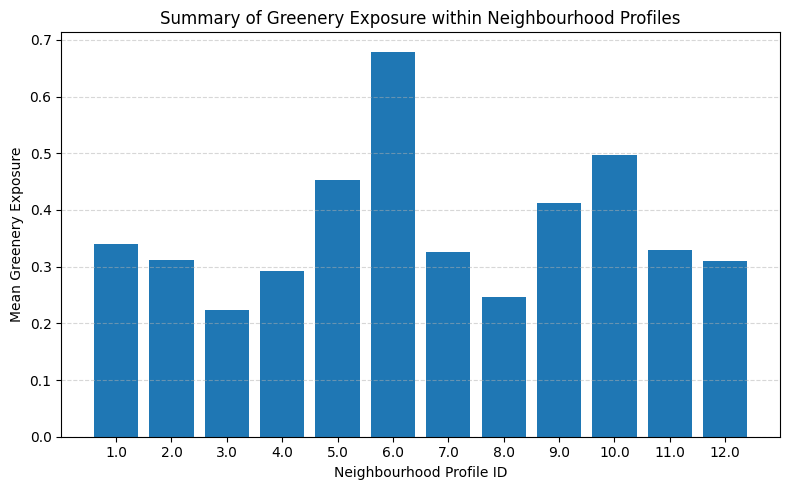

In [11]:
# Visualize results with a bar chart
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    cluster_summary["Neighbourhood Profile ID"].astype(str),
    cluster_summary["mean"]
)

ax.set_xlabel("Neighbourhood Profile ID")
ax.set_ylabel("Mean Greenery Exposure")
ax.set_title("Summary of Greenery Exposure within Neighbourhood Profiles")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()